In [16]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:
# Kaggle dataset
tsp_dataset_directory_path = kagglehub.dataset_download("patricklford/travelling-salesman-problem")
job_shop_dataset_directory_path = kagglehub.dataset_download("yidalin/1000jobshop")

tsp_dataset_path = tsp_dataset_directory_path + "/UK_Cities.csv"
job_shop_dataset_path = job_shop_dataset_directory_path + "/1000"

# Bin packing dataset from https://people.sc.fsu.edu/~jburkardt/datasets/bin_packing/bin_packing.html
bin_packing_capacity = 524
bin_packing_weights = [442, 252, 252, 252, 252, 252, 252, 252, 127, 127, 127, 127, 127, 106, 106, 106, 106, 85, 84, 46, 37, 37, 12, 12, 12, 10, 10, 10, 10, 10, 10, 9, 9]
bin_packing_assignment = [1 , 2, 2, 3, 3, 4, 4, 5, 5, 5, 6, 6, 6, 6, 7, 7, 7, 7, 7, 1, 6, 7, 1, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5]

tsp_dataset = pd.read_csv(tsp_dataset_path)
job_shop_dataset = pd.read_csv(job_shop_dataset_path, sep=r'\s+', skiprows=1, header=None)

raw_col = tsp_dataset.columns[0]
tsp_dataset = tsp_dataset[raw_col].str.split(",", expand=True)
tsp_dataset.columns = ["City", "Latitude", "Longitude", "Population"]
tsp_dataset["Latitude"] = pd.to_numeric(tsp_dataset["Latitude"], errors="coerce")
tsp_dataset["Longitude"] = pd.to_numeric(tsp_dataset["Longitude"], errors="coerce")
tsp_dataset["Population"] = pd.to_numeric(tsp_dataset["Population"], errors="coerce")

Using Colab cache for faster access to the 'travelling-salesman-problem' dataset.
Using Colab cache for faster access to the '1000jobshop' dataset.


In [18]:
print(tsp_dataset.head())
print(job_shop_dataset.head())

         City  Latitude  Longitude  Population
0      London   51.5074    -0.1278     8961989
1  Birmingham   52.4862    -1.8904     1153717
2       Leeds   53.8008    -1.5491      789194
3     Glasgow   55.8642    -4.2518      635640
4   Sheffield   53.3811    -1.4701      584853
         0          1          2          3          4          5    \
0  44.468910  57.065263  95.250600  83.800730  89.861289  15.846435   
1  82.900563  53.065417  61.409128  96.806655   7.424679  15.099752   
2  68.594734  18.568775  43.332650  89.195419  52.625048  63.918632   
3  41.870106  57.664315  24.371592  40.148461  38.195494  28.745332   
4  22.936728  63.217495  64.726159  42.658568  10.095368  49.332464   

         6          7          8          9    ...        990        991  \
0  78.709113  76.695076  35.856869  55.016766  ...  15.212137  58.833084   
1  17.822445  50.525471  72.101295  57.969568  ...  17.324023  26.281829   
2  49.252406  14.174969  32.662011  95.259896  ...  63.749772  

# **Travel Sales Problem (TSP)**

In [19]:
# Membuat matriks jarak untuk TSP

# Untuk menghitung jarak menggunakan rumus Haversine.
# Rumus Haversine digunakan untuk menghitung jarak antara dua titik
# di permukaan bumi berdasarkan koordinat lintang dan bujur mereka.
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Radius bumi dalam kilometer
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat / 2) ** 2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon / 2) ** 2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    return R * c

dist_matrix = np.zeros((len(tsp_dataset), len(tsp_dataset)))
for i in range(len(tsp_dataset)):
    for j in range(len(tsp_dataset)):
        dist_matrix[i][j] = haversine_distance(
            tsp_dataset.loc[i, "Latitude"],
            tsp_dataset.loc[i, "Longitude"],
            tsp_dataset.loc[j, "Latitude"],
            tsp_dataset.loc[j, "Longitude"]
        )

print(dist_matrix)

## Hitung total distance pada rute
def total_distance(route, dist_matrix):
    distance = 0
    for i in range(len(route) - 1):
        distance += dist_matrix[route[i]][route[i + 1]]
    distance += dist_matrix[route[-1]][route[0]]  # Kembali ke kota awal
    return distance

def route_to_city_path(route):
    route_int = [int(x) for x in route]
    names = [str(tsp_dataset.iloc[idx]["City"]) for idx in route_int]

    # Tambahkan kota awal lagi di belakang untuk menutup siklus TSP
    names.append(names[0])
    return " -> ".join(names)

[[  0.         162.4958406  272.42602816 ... 279.35171061 307.2430097
  245.16062882]
 [162.4958406    0.         147.93815876 ... 121.61713204 149.04222165
  121.68363071]
 [272.42602816 147.93815876   0.         ...  87.25656799  97.4149874
   27.95020546]
 ...
 [279.35171061 121.61713204  87.25656799 ...   0.          27.89235704
   83.66669725]
 [307.2430097  149.04222165  97.4149874  ...  27.89235704   0.
  101.14907969]
 [245.16062882 121.68363071  27.95020546 ...  83.66669725 101.14907969
    0.        ]]


## **Genetic Algorithm**

In [20]:
# Genetic Algorithm

population_size = 100 # Jumlah populasi
n_generations = 1000 # Jumlah generasi / iterasi
mutation_rate = 0.01 # Probabilitas mutasi
tsp_ga_iterations = n_generations
tsp_ga_history = []

# Fitness function untuk TSP, semakin kecil total distance, semakin baik fitness-nya
def fitness(route, dist_matrix):
    return 1 / total_distance(route, dist_matrix)

# Inisiasi populasi awal dengan rute acak
initial_population = [np.random.permutation(len(tsp_dataset)) for _ in range(population_size)]

# Tournament selection untuk memilih individu terbaik dari populasi
def tournament_selection(population, fitness_values, tournament_size=5):

    # Pilih beberapa individu secara acak untuk kompetisi
    selected_indices = np.random.choice(len(population), tournament_size, replace=False)

    # Evaluasi fitness dari individu yang dipilih
    selected_fitness = [fitness_values[i] for i in selected_indices]

    # Pilih individu dengan fitness terbaik sebagai pemenang
    winner_index = selected_indices[np.argmax(selected_fitness)]
    return population[winner_index]

# Crossover untuk menghasilkan anak dari dua orang tua
def crossover(parent1, parent2):
    # Simple order crossover (OX) for TSP

    # Memilih dua titik crossover secara acak
    start, end = sorted(np.random.choice(len(parent1), 2, replace=False))

    # Membuat anak dengan bagian dari parent1 dan sisanya dari parent2
    child = [-1] * len(parent1)
    child[start:end] = parent1[start:end]
    pointer = end

    # Mengisi sisa bagian anak dengan kota dari parent2
    for city in np.concatenate((parent2[end:], parent2[:end])):
        if city not in child:
            child[pointer % len(child)] = city
            pointer += 1
    return child

# Mutasi dengan swap dua kota secara acak
def mutate(route, mutation_rate=0.01):
    for i in range(len(route)):

        # Gacha untuk menentukan apakah akan melakukan mutasi atau tidak
        if np.random.rand() < mutation_rate:
            j = np.random.randint(len(route))
            route[i], route[j] = route[j], route[i]  # Swap dua kota
    return route


for generation in range(n_generations):
    # Evaluasi fitness dari populasi saat ini
    fitness_values = [fitness(route, dist_matrix) for route in initial_population]
    print(f"Generasi ke {generation + 1}, Best fitness: {max(fitness_values)}")

    # Pilih individu terbaik dari populasi
    best_individual = initial_population[np.argmax(fitness_values)]
    best_distance_current = total_distance(best_individual, dist_matrix)
    tsp_ga_history.append((generation + 1, float(best_distance_current)))

    print(f"Individu terbaik saat ini: {[int(x) for x in best_individual]}, Total distance: {best_distance_current}")

    # Seleksi individu untuk crossover
    parent1 = tournament_selection(initial_population, fitness_values)
    parent2 = tournament_selection(initial_population, fitness_values)
    print(f"Parent 1: {[int(x) for x in parent1]}, Fitness: {fitness(parent1, dist_matrix)}")
    print(f"Parent 2: {[int(x) for x in parent2]}, Fitness: {fitness(parent2, dist_matrix)}")

    # Crossover untuk menghasilkan anak
    child = crossover(parent1, parent2)
    print(f"Anak hasil crossover: {[int(x) for x in child]}, Fitness: {fitness(child, dist_matrix)}")

    # Mutasi pada anak
    child = mutate(child, mutation_rate)
    print(f"Anak setelah mutasi: {[int(x) for x in child]}, Fitness: {fitness(child, dist_matrix)}")

    # Gantilah individu terburuk di populasi dengan anak yang dihasilkan
    worst_index = np.argmin(fitness_values)
    print(f"Individu terburuk: {[int(x) for x in initial_population[worst_index]]}, Fitness: {fitness_values[worst_index]}")

    initial_population[worst_index] = child
    print(f"Individu terburuk digantikan dengan anak: {[int(x) for x in child]}, Fitness: {fitness(child, dist_matrix)}")
    print(f"Rute terbaik saat ini: {route_to_city_path(best_individual)}")
    print(f"Total distance rute terbaik saat ini: {total_distance(best_individual, dist_matrix)}\n")

# Setelah semua generasi selesai, ambil individu terbaik sebagai solusi akhir
ga_best_route = [int(x) for x in initial_population[np.argmax(fitness_values)]]
ga_best_distance = total_distance(ga_best_route, dist_matrix)
ga_best_route_cities = route_to_city_path(ga_best_route)

print("Best route (index):", ga_best_route)
print("Best route (kota):", ga_best_route_cities)
print("Best distance:", ga_best_distance)

Streaming output truncated to the last 5000 lines.
Rute terbaik saat ini: Newcastle upon Tyne -> Sunderland -> Hull -> Peterborough -> Brighton -> London -> Woking -> Southampton -> Cambridge -> Luton -> Leicester -> Manchester -> Liverpool -> Derby -> Southport -> Coventry -> Cardiff -> Plymouth -> Barnsley -> Huddersfield -> Leeds -> Aberdeen -> Middlesbrough -> Warrington -> Northampton -> Sheffield -> Bradford -> Glasgow -> Edinburgh -> Wolverhampton -> St Helens -> Milton Keynes -> Crawley -> Reading -> Portsmouth -> Oxford -> Nottingham -> Exeter -> Bristol -> Swindon -> Ipswich -> Norwich -> Oldham -> Blackpool -> Birmingham -> Southend-on-Sea -> Stoke-on-Trent -> Stockport -> York -> Newcastle upon Tyne
Total distance rute terbaik saat ini: 6962.582672449788

Generasi ke 547, Best fitness: 0.00014362486551964336
Individu terbaik saat ini: [14, 18, 19, 32, 15, 0, 43, 24, 39, 17, 12, 5, 7, 21, 47, 10, 11, 20, 48, 37, 2, 28, 36, 34, 29, 4, 6, 3, 8, 23, 46, 27, 44, 30, 25, 38, 13, 

## **Simulated Annealing**

In [21]:
# Simulated Annealing

T_start = 5000
T_min = 1
cooling_rate = 0.995
max_iteration = 10000

def swap_city(route, i, k):
    return route[:i] + route[i:k+1][::-1] + route[k+1:]

def get_neighbor(route):
    i, k = sorted(np.random.choice(len(route), 2, replace=False))
    return swap_city(route, i, k)

# Inisialisasi
current_route = np.random.permutation(len(tsp_dataset)).tolist()
current_distance = total_distance(current_route, dist_matrix)

best_route = current_route[:]
best_distance = current_distance

temp = T_start
total_iterations = 0
solution_accepted = 0
tsp_sa_history = [(0, float(best_distance))]

# Histori untuk convergence chart
best_distance_history = [best_distance]
current_distance_history = [current_distance]
temperature_history = [temp]

while temp > T_min and total_iterations < max_iteration:
    neighbor = get_neighbor(current_route)
    neighbor_distance = total_distance(neighbor, dist_matrix)

    if neighbor_distance < current_distance:
        current_route = neighbor
        current_distance = neighbor_distance
        solution_accepted += 1
    else:
        acceptance_probability = np.exp((current_distance - neighbor_distance) / temp)
        if np.random.rand() < acceptance_probability:
            current_route = neighbor
            current_distance = neighbor_distance
            solution_accepted += 1

    if current_distance < best_distance:
        best_route = current_route[:]
        best_distance = current_distance

    tsp_sa_history.append((total_iterations + 1, float(best_distance)))

    best_distance_history.append(best_distance)
    current_distance_history.append(current_distance)
    temperature_history.append(temp)

    if total_iterations % 50 == 0:
        print(f"Iterasi {total_iterations}, Temperatur: {temp:.2f}, Best distance: {best_distance:.4f}")

    temp *= cooling_rate
    total_iterations += 1

# Hasil akhir
sa_best_route = best_route
sa_best_distance = best_distance
sa_best_route_cities = route_to_city_path(sa_best_route)
acceptance_rate = (solution_accepted / total_iterations * 100) if total_iterations > 0 else 0
tsp_sa_iterations = total_iterations

print("Best route (index):", sa_best_route)
print("Best route (kota):", sa_best_route_cities)
print("Best distance:", sa_best_distance)
print("Jumlah solusi yang diterima:", solution_accepted)
print("Total iterasi:", total_iterations)

Iterasi 0, Temperatur: 5000.00, Best distance: 10018.9361
Iterasi 50, Temperatur: 3891.56, Best distance: 10018.9361
Iterasi 100, Temperatur: 3028.85, Best distance: 10018.9361
Iterasi 150, Temperatur: 2357.39, Best distance: 10018.9361
Iterasi 200, Temperatur: 1834.79, Best distance: 9660.3428
Iterasi 250, Temperatur: 1428.04, Best distance: 9660.3428
Iterasi 300, Temperatur: 1111.46, Best distance: 9660.3428
Iterasi 350, Temperatur: 865.06, Best distance: 9660.3428
Iterasi 400, Temperatur: 673.29, Best distance: 9660.3428
Iterasi 450, Temperatur: 524.03, Best distance: 9130.1204
Iterasi 500, Temperatur: 407.86, Best distance: 9130.1204
Iterasi 550, Temperatur: 317.44, Best distance: 8849.4400
Iterasi 600, Temperatur: 247.07, Best distance: 8849.4400
Iterasi 650, Temperatur: 192.30, Best distance: 8849.4400
Iterasi 700, Temperatur: 149.67, Best distance: 8849.4400
Iterasi 750, Temperatur: 116.49, Best distance: 8313.7174
Iterasi 800, Temperatur: 90.66, Best distance: 7864.3727
Iterasi

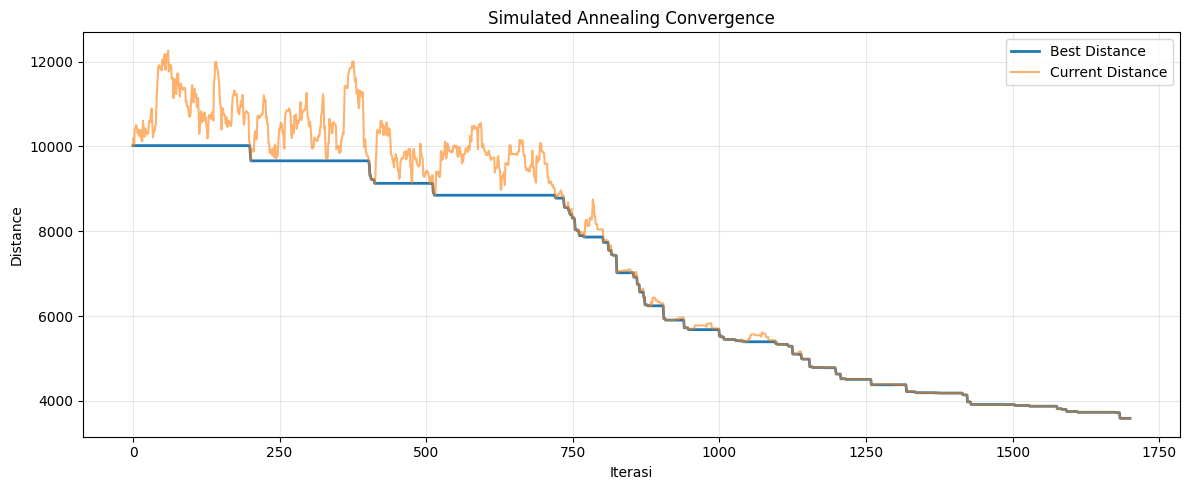

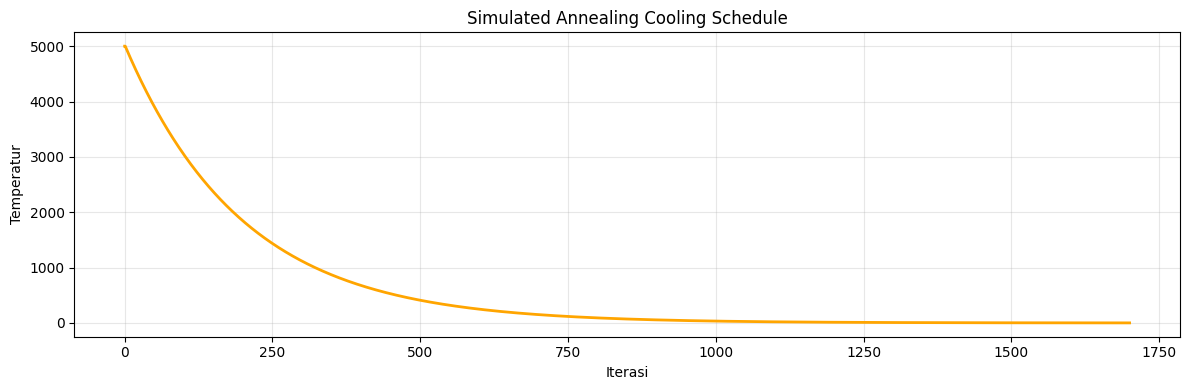

In [22]:
plt.figure(figsize=(12, 5))
plt.plot(best_distance_history, label="Best Distance", linewidth=2)
plt.plot(current_distance_history, label="Current Distance", alpha=0.6)
plt.xlabel("Iterasi")
plt.ylabel("Distance")
plt.title("Simulated Annealing Convergence")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(temperature_history, color="orange", linewidth=2)
plt.xlabel("Iterasi")
plt.ylabel("Temperatur")
plt.title("Simulated Annealing Cooling Schedule")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

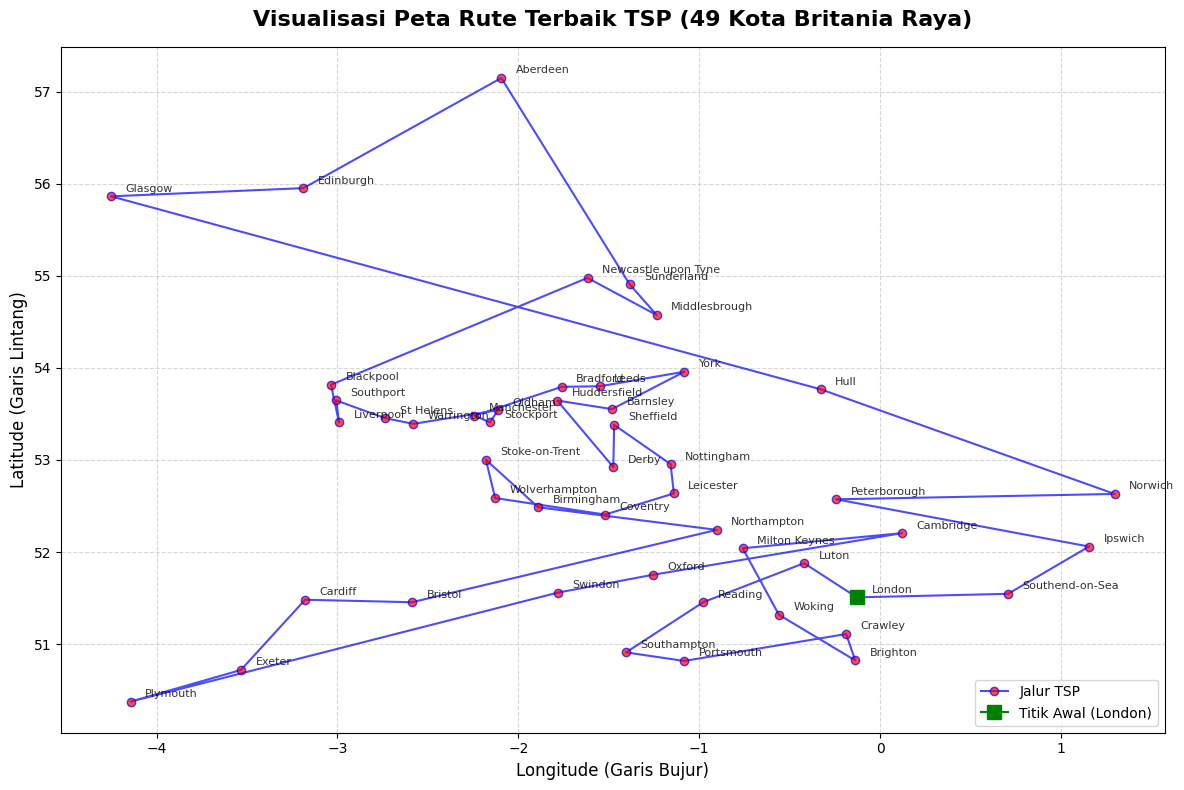

In [23]:
# --- Asumsi variabel sa_best_route dan tsp_dataset sudah ada dari kode sebelumnya ---

# 1. Ekstrak koordinat X (Longitude) dan Y (Latitude) berdasarkan urutan rute terbaik
route_lons = [tsp_dataset.loc[idx, "Longitude"] for idx in sa_best_route]
route_lats = [tsp_dataset.loc[idx, "Latitude"] for idx in sa_best_route]

# 2. Tutup siklus rute: Tambahkan koordinat kota awal ke urutan paling akhir
route_lons.append(route_lons[0])
route_lats.append(route_lats[0])

# 3. Setup ukuran figur/kanvas (Lebar 12, Tinggi 8 untuk proporsi yang enak dilihat)
plt.figure(figsize=(12, 8))

# 4. Gambar garis rute beserta titik kotanya
# Garis berwarna biru (alpha 0.7 agar agak transparan), titik berwarna merah
plt.plot(route_lons, route_lats, color='blue', linestyle='-', linewidth=1.5,
         marker='o', markersize=6, markerfacecolor='red', label='Jalur TSP', alpha=0.7)

# 5. Tandai titik awal keberangkatan (Start Point) dengan kotak hijau besar
plt.plot(route_lons[0], route_lats[0], marker='s', color='green', markersize=10,
         label=f'Titik Awal ({tsp_dataset.loc[sa_best_route[0], "City"]})')

# 6. (Opsional) Tambahkan label nama kota di sebelah titik koordinatnya
# Kita gunakan font ukuran 8 dan sedikit transparansi agar tidak terlalu penuh
for idx in sa_best_route:
    plt.text(tsp_dataset.loc[idx, "Longitude"] + 0.08,  # Geser teks sedikit ke kanan (X)
             tsp_dataset.loc[idx, "Latitude"] + 0.05,   # Geser teks sedikit ke atas (Y)
             tsp_dataset.loc[idx, "City"],
             fontsize=8, alpha=0.8)

# 7. Kustomisasi Estetika Grafik
plt.title('Visualisasi Peta Rute Terbaik TSP (49 Kota Britania Raya)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Longitude (Garis Bujur)', fontsize=12)
plt.ylabel('Latitude (Garis Lintang)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=10)

# 8. Render dan tampilkan plot
plt.tight_layout()
plt.show()

## **Ant Colony Optimization (ACO)**

In [24]:
# Ant Colony Optimization (ACO)

def build_eta_matrix(dist_matrix):
    with np.errstate(divide='ignore'):
        eta_matrix = 1 / dist_matrix
        eta_matrix[dist_matrix == 0] = 0  # Hindari pembagian dengan nol
    return eta_matrix

def build_route_one_ant(start, pheromone_matrix, eta_matrix, alpha, beta):
    route = [start]
    visited = set(route)

    for _ in range(1, len(dist_matrix)):
        current_city = route[-1]
        probabilities = []
        for next_city in range(len(dist_matrix)):
            if next_city not in visited:
                tau = pheromone_matrix[current_city][next_city] ** alpha
                eta = eta_matrix[current_city][next_city] ** beta
                probabilities.append(tau * eta)
            else:
                probabilities.append(0)

        probabilities = np.array(probabilities)
        probabilities /= probabilities.sum()  # Normalisasi ke probabilitas

        next_city = np.random.choice(len(dist_matrix), p=probabilities)
        route.append(next_city)
        visited.add(next_city)

    return route

def update_pheromone(pheromone_matrix, routes, dist_matrix, evaporation_rate, deposit_amount):
    pheromone_matrix *= (1 - evaporation_rate)  # Evaporasi
    for route in routes:
        route_distance = total_distance(route, dist_matrix)
        for i in range(len(route) - 1):
            pheromone_matrix[route[i]][route[i + 1]] += deposit_amount / route_distance
        pheromone_matrix[route[-1]][route[0]] += deposit_amount / route_distance  # Kembali ke kota awal


ants = 100
max_iterations = 1000
tsp_aco_iterations = max_iterations
alpha = 1.0
beta = 5.0
evaporation_rate = 0.5
deposit_amount = 100
initial_pheromone = 1.0

# Inisialisasi matriks pheromone dan eta
pheromone_matrix = np.full(dist_matrix.shape, initial_pheromone)
eta_matrix = build_eta_matrix(dist_matrix)

best_route = None
best_distance = float('inf')
tsp_aco_history = []

for iteration in range(max_iterations):
    routes = []
    for ant in range(ants):
        start_city = np.random.randint(len(dist_matrix))
        route = build_route_one_ant(start_city, pheromone_matrix, eta_matrix, alpha, beta)
        routes.append(route)

    update_pheromone(pheromone_matrix, routes, dist_matrix, evaporation_rate, deposit_amount)

    # Evaluasi rute terbaik dari iterasi ini
    for route in routes:
        route_distance = total_distance(route, dist_matrix)
        if route_distance < best_distance:
            best_distance = route_distance
            best_route = route

    tsp_aco_history.append((iteration + 1, float(best_distance)))

    if iteration % 50 == 0:
        print(f"Iterasi {iteration}, Best distance: {best_distance:.4f}")

aco_best_route = best_route
aco_best_distance = best_distance
aco_best_route_cities = route_to_city_path(best_route)

print("Best route (index):", aco_best_route)
print("Best route (kota):", aco_best_route_cities)
print("Best distance:", aco_best_distance)

Iterasi 0, Best distance: 3068.6420
Iterasi 50, Best distance: 2753.4027
Iterasi 100, Best distance: 2753.4027
Iterasi 150, Best distance: 2753.4027
Iterasi 200, Best distance: 2749.4063
Iterasi 250, Best distance: 2749.4063
Iterasi 300, Best distance: 2749.4063
Iterasi 350, Best distance: 2749.4063
Iterasi 400, Best distance: 2749.4063
Iterasi 450, Best distance: 2749.4063
Iterasi 500, Best distance: 2749.4063
Iterasi 550, Best distance: 2749.4063
Iterasi 600, Best distance: 2749.4063
Iterasi 650, Best distance: 2749.4063
Iterasi 700, Best distance: 2749.4063
Iterasi 750, Best distance: 2749.4063
Iterasi 800, Best distance: 2749.4063
Iterasi 850, Best distance: 2749.4063
Iterasi 900, Best distance: 2749.4063
Iterasi 950, Best distance: 2749.4063
Best route (index): [15, 44, 43, 0, 45, 41, 33, 39, 32, 12, 13, 21, 4, 48, 37, 6, 2, 35, 19, 36, 18, 14, 8, 3, 28, 40, 47, 7, 46, 34, 5, 26, 16, 22, 23, 1, 10, 29, 27, 17, 30, 38, 31, 9, 11, 42, 20, 24, 25]
Best route (kota): Brighton -> Crawl

## **Particle Swarm Optimization (PSO)**

In [25]:
# Particle Swarm Optimization (PSO)

def route_subtract(target, source):
    # Return swap sequence to transform source -> target
    current = source[:]
    swaps = []
    for i in range(len(target)):
        if current[i] != target[i]:
            j = current.index(target[i])
            swaps.append((i, j))
            current[i], current[j] = current[j], current[i]
    return swaps

def apply_swaps(route, swaps):
    new_route = route[:]
    for i, j in swaps:
        new_route[i], new_route[j] = new_route[j], new_route[i]
    return new_route

def sample_swaps(swaps, prob, rng):
    # Keep order, sample by probability
    if not swaps or prob <= 0:
        return []
    p = min(1.0, prob)
    chosen_idx = [k for k in range(len(swaps)) if rng.random() < p]

    # Avoid empty velocity component so particle still moves sometimes
    if not chosen_idx:
        chosen_idx = [rng.integers(0, len(swaps))]

    return [swaps[k] for k in chosen_idx]

def merge_velocity(components, max_len):
    # Merge while preserving order and removing duplicates
    merged = []
    seen = set()

    for comp in components:
        for s in comp:
            if s not in seen:
                merged.append(s)
                seen.add(s)
            if len(merged) >= max_len:
                return merged
    return merged

def initialize_particles(num_particles, num_cities, dist_matrix, rng):
    particles = []
    for _ in range(num_particles):
        pos = rng.permutation(num_cities).tolist()
        dist = total_distance(pos, dist_matrix)
        particles.append({
            "position": pos,
            "velocity": [],
            "best_position": pos[:],
            "best_distance": dist
        })
    return particles

# Hyperparameters
num_particles = 80
max_iterations = 1500
tsp_pso_iterations = max_iterations

inertia_weight = 0.8
cognitive_weight = 1.7
social_weight = 1.7

max_velocity_ratio = 0.35
mutation_rate = 0.15

rng = np.random.default_rng(42)

num_cities = len(dist_matrix)
max_velocity = max(2, int(np.ceil(max_velocity_ratio * num_cities)))

particles = initialize_particles(num_particles, num_cities, dist_matrix, rng)

# Initialize global best from particles
best_particle = min(particles, key=lambda p: p["best_distance"])
global_best_position = best_particle["best_position"][:]
global_best_distance = best_particle["best_distance"]
tsp_pso_history = []

for iteration in range(max_iterations):
    # Evaluate and update personal/global best
    for particle in particles:
        current_distance = total_distance(particle["position"], dist_matrix)

        if current_distance < particle["best_distance"]:
            particle["best_position"] = particle["position"][:]
            particle["best_distance"] = current_distance

        if current_distance < global_best_distance:
            global_best_position = particle["position"][:]
            global_best_distance = current_distance

    # Update velocity and position
    for particle in particles:
        inertia_component = sample_swaps(particle["velocity"], inertia_weight, rng)

        cognitive_swaps = route_subtract(particle["best_position"], particle["position"])
        social_swaps = route_subtract(global_best_position, particle["position"])

        r1 = rng.random()
        r2 = rng.random()

        cognitive_component = sample_swaps(cognitive_swaps, cognitive_weight * r1, rng)
        social_component = sample_swaps(social_swaps, social_weight * r2, rng)

        new_velocity = merge_velocity(
            [inertia_component, cognitive_component, social_component],
            max_velocity
        )

        particle["velocity"] = new_velocity
        new_position = apply_swaps(particle["position"], particle["velocity"])

        # Small mutation to escape local minima
        if rng.random() < mutation_rate:
            i, j = rng.choice(num_cities, size=2, replace=False)
            new_position[i], new_position[j] = new_position[j], new_position[i]

        particle["position"] = new_position

    tsp_pso_history.append((iteration + 1, float(global_best_distance)))

    if iteration % 50 == 0:
        print(f"Iterasi {iteration}, Best distance: {global_best_distance:.4f}")

pso_best_route = global_best_position
pso_best_distance = global_best_distance
pso_best_route_cities = route_to_city_path(global_best_position)

print("Best route (index):", pso_best_route)
print("Best route (kota):", pso_best_route_cities)
print("Best distance:", pso_best_distance)

Iterasi 0, Best distance: 9551.2809
Iterasi 50, Best distance: 7571.0178
Iterasi 100, Best distance: 7476.3340
Iterasi 150, Best distance: 7414.5235
Iterasi 200, Best distance: 7320.2421
Iterasi 250, Best distance: 7320.2421
Iterasi 300, Best distance: 7149.6001
Iterasi 350, Best distance: 6990.6040
Iterasi 400, Best distance: 6800.4483
Iterasi 450, Best distance: 6800.4483
Iterasi 500, Best distance: 6608.2313
Iterasi 550, Best distance: 6443.0417
Iterasi 600, Best distance: 6362.1886
Iterasi 650, Best distance: 6343.1908
Iterasi 700, Best distance: 6109.9437
Iterasi 750, Best distance: 6109.2029
Iterasi 800, Best distance: 5988.5432
Iterasi 850, Best distance: 5988.5432
Iterasi 900, Best distance: 5988.5432
Iterasi 950, Best distance: 5988.5432
Iterasi 1000, Best distance: 5988.5432
Iterasi 1050, Best distance: 5988.5432
Iterasi 1100, Best distance: 5988.5432
Iterasi 1150, Best distance: 5988.5432
Iterasi 1200, Best distance: 5988.5432
Iterasi 1250, Best distance: 5988.5432
Iterasi 1

## Evaluasi

In [26]:
# Evaluasi dan perbandingan GA, SA, ACO, PSO
evaluation_data = {
    "Algoritma": ["GA", "SA", "ACO", "PSO"],
    "Best Distance": [
        float(ga_best_distance),
        float(sa_best_distance),
        float(aco_best_distance),
        float(pso_best_distance)
    ],
    "Iterasi": [
        int(tsp_ga_iterations),
        int(tsp_sa_iterations),
        int(tsp_aco_iterations),
        int(tsp_pso_iterations)
    ]
}

df_evaluation = pd.DataFrame(evaluation_data)
df_evaluation = df_evaluation.sort_values("Best Distance", ascending=True).reset_index(drop=True)
df_evaluation["Rank"] = df_evaluation["Best Distance"].rank(method="dense").astype(int)

best_algorithm_idx = df_evaluation["Best Distance"].idxmin()
best_algo = df_evaluation.loc[best_algorithm_idx, "Algoritma"]
best_dist = df_evaluation.loc[best_algorithm_idx, "Best Distance"]

print(f"Algoritma terbaik: {best_algo} (Best Distance = {best_dist:.4f})")
display(  # ty:ignore[unresolved-reference]
    df_evaluation.style
        .format({"Best Distance": "{:.4f}", "Iterasi": "{:.0f}"})
)

Algoritma terbaik: ACO (Best Distance = 2749.4063)


,Algoritma,Best Distance,Iterasi,Rank
0,ACO,2749.4063,1000,1
1,SA,3591.2706,1700,2
2,PSO,5988.5432,1500,3
3,GA,6477.6538,1000,4


# **Job Shop Scheduling**

In [27]:
# Menyiapkan representasi problem Job Shop Scheduling (JSS)

def parse_job_shop_dataset(df):
    jobs = []

    for _, row in df.iterrows():
        values = [int(v) for v in row.dropna().tolist()]
        if not values:
            continue

        # Beberapa format menyimpan id job di kolom pertama
        if len(values) % 2 == 1:
            values = values[1:]

        ops = []
        for i in range(0, len(values) - 1, 2):
            machine_id = int(values[i])
            process_time = int(values[i + 1])
            if process_time > 0:
                ops.append((machine_id, process_time))

        if ops:
            jobs.append(ops)

    if not jobs:
        raise ValueError("Dataset Job Shop kosong atau format tidak terbaca")

    machine_ids = sorted({m for ops in jobs for m, _ in ops})
    machine_offset = machine_ids[0]

    jobs_normalized = [
        [(m - machine_offset, p) for m, p in ops]
        for ops in jobs
    ]

    return jobs_normalized


def build_operation_counts(job_operations):
    return [len(ops) for ops in job_operations]


def build_random_sequence(operation_counts, rng):
    sequence = []
    for job_id, count in enumerate(operation_counts):
        sequence.extend([job_id] * count)
    rng.shuffle(sequence)
    return sequence


def is_valid_jss_sequence(sequence, operation_counts):
    if len(sequence) != sum(operation_counts):
        return False

    counts = [0] * len(operation_counts)
    for job_id in sequence:
        if job_id < 0 or job_id >= len(operation_counts):
            return False
        counts[job_id] += 1

    return counts == operation_counts


def decode_sequence_to_schedule(sequence, job_operations):
    num_jobs = len(job_operations)
    num_machines = max(m for ops in job_operations for m, _ in ops) + 1

    job_next_op = [0] * num_jobs
    job_ready_time = [0.0] * num_jobs
    machine_ready_time = [0.0] * num_machines
    schedule = []

    for job_id in sequence:
        op_idx = job_next_op[job_id]

        if op_idx >= len(job_operations[job_id]):
            return float("inf"), [], False

        machine_id, process_time = job_operations[job_id][op_idx]

        start_time = max(job_ready_time[job_id], machine_ready_time[machine_id])
        end_time = start_time + process_time

        schedule.append({
            "job": job_id,
            "operation": op_idx,
            "machine": machine_id,
            "start": start_time,
            "end": end_time,
            "duration": process_time
        })

        job_ready_time[job_id] = end_time
        machine_ready_time[machine_id] = end_time
        job_next_op[job_id] += 1

    # Pastikan semua operasi dari setiap job sudah terjadwalkan
    valid = all(job_next_op[j] == len(job_operations[j]) for j in range(num_jobs))
    makespan_value = max(machine_ready_time) if valid else float("inf")

    return makespan_value, schedule, valid


def makespan(sequence, job_operations):
    value, _, valid = decode_sequence_to_schedule(sequence, job_operations)
    return value if valid else float("inf")


def sequence_to_job_path(sequence):
    return " -> ".join([f"J{job_id}" for job_id in sequence])


rng = np.random.default_rng(42)

job_operations_full = parse_job_shop_dataset(job_shop_dataset)

# Agar runtime notebook tetap masuk akal, gunakan subset job dan operasi per job
jss_job_limit = 12
jss_operation_limit_per_job = 20

job_operations = job_operations_full[:jss_job_limit]
job_operations = [ops[:jss_operation_limit_per_job] for ops in job_operations]

operation_counts = build_operation_counts(job_operations)
num_jobs = len(job_operations)
num_machines = max(m for ops in job_operations for m, _ in ops) + 1

test_sequence = build_random_sequence(operation_counts, rng)
test_makespan, test_schedule, test_valid = decode_sequence_to_schedule(test_sequence, job_operations)

print(f"Jumlah job (subset): {num_jobs}")
print(f"Jumlah mesin: {num_machines}")
print(f"Operasi per job (maks): {jss_operation_limit_per_job}")
print(f"Total operasi: {sum(operation_counts)}")
print(f"Sequence valid: {test_valid}")
print(f"Contoh makespan awal: {test_makespan:.2f}")
print(f"Contoh urutan job: {sequence_to_job_path(test_sequence[:20])} ...")

Jumlah job (subset): 12
Jumlah mesin: 99
Operasi per job (maks): 20
Total operasi: 240
Sequence valid: True
Contoh makespan awal: 1546.00
Contoh urutan job: J11 -> J5 -> J6 -> J3 -> J5 -> J0 -> J6 -> J4 -> J11 -> J7 -> J2 -> J3 -> J1 -> J5 -> J10 -> J5 -> J8 -> J11 -> J2 -> J6 ...


## **Genetic Algorithm**

In [28]:
# Genetic Algorithm untuk Job Shop Scheduling

population_size = 80
n_generations = 600
mutation_rate = 0.12
ga_iterations = n_generations
jss_ga_history = []

def fitness(sequence, job_operations):
    mk = makespan(sequence, job_operations)
    return 0.0 if not np.isfinite(mk) else 1.0 / (1.0 + mk)


def tournament_selection(population, fitness_values, tournament_size=5):
    selected_indices = np.random.choice(len(population), tournament_size, replace=False)
    selected_fitness = [fitness_values[i] for i in selected_indices]
    winner_index = selected_indices[np.argmax(selected_fitness)]
    return population[winner_index][:]


def count_preserving_crossover(parent1, parent2, operation_counts, rng):
    child = [-1] * len(parent1)
    used_counts = [0] * len(operation_counts)

    mask = rng.random(len(parent1)) < 0.5

    for i, keep_gene in enumerate(mask):
        if keep_gene:
            gene = parent1[i]
            if used_counts[gene] < operation_counts[gene]:
                child[i] = gene
                used_counts[gene] += 1

    for gene in parent2:
        if used_counts[gene] >= operation_counts[gene]:
            continue

        insert_idx = child.index(-1)
        child[insert_idx] = gene
        used_counts[gene] += 1

    return child


def mutate_sequence(sequence, mutation_rate, rng):
    new_sequence = sequence[:]
    for i in range(len(new_sequence)):
        if rng.random() < mutation_rate:
            j = int(rng.integers(0, len(new_sequence)))
            new_sequence[i], new_sequence[j] = new_sequence[j], new_sequence[i]
    return new_sequence


initial_population = [build_random_sequence(operation_counts, rng) for _ in range(population_size)]

for generation in range(n_generations):
    fitness_values = [fitness(sequence, job_operations) for sequence in initial_population]

    best_idx = int(np.argmax(fitness_values))
    best_individual = initial_population[best_idx][:]
    best_individual_makespan = makespan(best_individual, job_operations)
    jss_ga_history.append((generation + 1, float(best_individual_makespan)))

    parent1 = tournament_selection(initial_population, fitness_values)
    parent2 = tournament_selection(initial_population, fitness_values)

    child = count_preserving_crossover(parent1, parent2, operation_counts, rng)
    child = mutate_sequence(child, mutation_rate, rng)

    worst_index = int(np.argmin(fitness_values))
    initial_population[worst_index] = child

    if generation % 50 == 0:
        print(f"Generasi ke {generation + 1}, Best fitness: {fitness_values[best_idx]:.8f}")
        print(f"Best makespan saat ini: {best_individual_makespan:.2f}")
        print(f"Urutan job terbaik saat ini: {sequence_to_job_path(best_individual[:20])} ...\n")

final_fitness_values = [fitness(sequence, job_operations) for sequence in initial_population]
final_best_idx = int(np.argmax(final_fitness_values))

jss_ga_best_sequence = initial_population[final_best_idx][:]
jss_ga_best_makespan = makespan(jss_ga_best_sequence, job_operations)
jss_ga_best_sequence_jobs = sequence_to_job_path(jss_ga_best_sequence)

print("Best sequence:", jss_ga_best_sequence)
print("Best sequence (job):", jss_ga_best_sequence_jobs)
print("Best makespan:", jss_ga_best_makespan)

Generasi ke 1, Best fitness: 0.00072359
Best makespan saat ini: 1381.00
Urutan job terbaik saat ini: J2 -> J8 -> J9 -> J6 -> J3 -> J7 -> J6 -> J5 -> J6 -> J6 -> J1 -> J2 -> J4 -> J11 -> J4 -> J7 -> J0 -> J5 -> J2 -> J9 ...

Generasi ke 51, Best fitness: 0.00072359
Best makespan saat ini: 1381.00
Urutan job terbaik saat ini: J2 -> J8 -> J9 -> J6 -> J3 -> J7 -> J6 -> J5 -> J6 -> J6 -> J1 -> J2 -> J4 -> J11 -> J4 -> J7 -> J0 -> J5 -> J2 -> J9 ...

Generasi ke 101, Best fitness: 0.00072359
Best makespan saat ini: 1381.00
Urutan job terbaik saat ini: J2 -> J8 -> J9 -> J6 -> J3 -> J7 -> J6 -> J5 -> J6 -> J6 -> J1 -> J2 -> J4 -> J11 -> J4 -> J7 -> J0 -> J5 -> J2 -> J9 ...

Generasi ke 151, Best fitness: 0.00074405
Best makespan saat ini: 1343.00
Urutan job terbaik saat ini: J11 -> J8 -> J8 -> J0 -> J5 -> J6 -> J3 -> J9 -> J8 -> J0 -> J7 -> J6 -> J2 -> J10 -> J6 -> J4 -> J4 -> J6 -> J1 -> J9 ...

Generasi ke 201, Best fitness: 0.00074683
Best makespan saat ini: 1338.00
Urutan job terbaik saat 

## **Simulated Annealing**

In [29]:
# Simulated Annealing untuk Job Shop Scheduling

def get_neighbor(sequence, rng):
    neighbor = sequence[:]
    i, j = sorted(rng.choice(len(neighbor), size=2, replace=False))
    neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
    return neighbor


T_start = 5000.0
T_min = 1.0
cooling_rate = 0.995
max_iteration = 10000

current_sequence = build_random_sequence(operation_counts, rng)
current_makespan = makespan(current_sequence, job_operations)
best_sequence = current_sequence[:]
best_makespan = current_makespan

solution_accepted = 0
total_iterations = 0
jss_sa_history = [(0, float(best_makespan))]

while T_start > T_min and total_iterations < max_iteration:
    neighbor = get_neighbor(current_sequence, rng)
    neighbor_makespan = makespan(neighbor, job_operations)

    if neighbor_makespan < current_makespan:
        current_sequence = neighbor
        current_makespan = neighbor_makespan
        solution_accepted += 1
    else:
        acceptance_probability = np.exp((current_makespan - neighbor_makespan) / T_start)
        if rng.random() < acceptance_probability:
            current_sequence = neighbor
            current_makespan = neighbor_makespan
            solution_accepted += 1

    if current_makespan < best_makespan:
        best_sequence = current_sequence[:]
        best_makespan = current_makespan

    jss_sa_history.append((total_iterations + 1, float(best_makespan)))

    if total_iterations % 50 == 0:
        print(f"Iterasi {total_iterations}, Temperatur: {T_start:.2f}, Best makespan: {best_makespan:.2f}")

    T_start *= cooling_rate
    total_iterations += 1

jss_sa_best_sequence = best_sequence
jss_sa_best_makespan = best_makespan
jss_sa_best_sequence_jobs = sequence_to_job_path(best_sequence)
sa_iterations = total_iterations

print("Best sequence:", jss_sa_best_sequence)
print("Best sequence (job):", jss_sa_best_sequence_jobs)
print("Best makespan:", jss_sa_best_makespan)
print("Jumlah solusi yang diterima:", solution_accepted)
print("Total iterasi:", total_iterations)

Iterasi 0, Temperatur: 5000.00, Best makespan: 1432.00
Iterasi 50, Temperatur: 3891.56, Best makespan: 1432.00
Iterasi 100, Temperatur: 3028.85, Best makespan: 1432.00
Iterasi 150, Temperatur: 2357.39, Best makespan: 1432.00
Iterasi 200, Temperatur: 1834.79, Best makespan: 1432.00
Iterasi 250, Temperatur: 1428.04, Best makespan: 1432.00
Iterasi 300, Temperatur: 1111.46, Best makespan: 1432.00
Iterasi 350, Temperatur: 865.06, Best makespan: 1432.00
Iterasi 400, Temperatur: 673.29, Best makespan: 1430.00
Iterasi 450, Temperatur: 524.03, Best makespan: 1430.00
Iterasi 500, Temperatur: 407.86, Best makespan: 1408.00
Iterasi 550, Temperatur: 317.44, Best makespan: 1354.00
Iterasi 600, Temperatur: 247.07, Best makespan: 1354.00
Iterasi 650, Temperatur: 192.30, Best makespan: 1354.00
Iterasi 700, Temperatur: 149.67, Best makespan: 1354.00
Iterasi 750, Temperatur: 116.49, Best makespan: 1350.00
Iterasi 800, Temperatur: 90.66, Best makespan: 1341.00
Iterasi 850, Temperatur: 70.56, Best makespan

## **Ant Colony Optimization (ACO)**

In [30]:
# Ant Colony Optimization (ACO) untuk Job Shop Scheduling

def build_job_eta(job_operations):
    avg_process_time = []
    for ops in job_operations:
        avg_process_time.append(np.mean([p for _, p in ops]))

    avg_process_time = np.array(avg_process_time, dtype=float)
    with np.errstate(divide="ignore"):
        eta = 1.0 / avg_process_time
    eta[~np.isfinite(eta)] = 0.0
    return eta


def build_sequence_one_ant(operation_counts, pheromone_matrix, eta, alpha, beta, rng):
    remaining = operation_counts[:]
    sequence = []
    total_ops = sum(operation_counts)

    for pos in range(total_ops):
        probabilities = np.zeros(len(operation_counts), dtype=float)

        for job_id in range(len(operation_counts)):
            if remaining[job_id] > 0:
                tau = pheromone_matrix[pos][job_id] ** alpha
                heuristic = eta[job_id] ** beta
                probabilities[job_id] = tau * heuristic

        if probabilities.sum() <= 0:
            candidates = [job_id for job_id in range(len(operation_counts)) if remaining[job_id] > 0]
            selected_job = int(rng.choice(candidates))
        else:
            probabilities /= probabilities.sum()
            selected_job = int(rng.choice(len(operation_counts), p=probabilities))

        sequence.append(selected_job)
        remaining[selected_job] -= 1

    return sequence


def update_pheromone(pheromone_matrix, sequences, makespans, evaporation_rate, deposit_amount):
    pheromone_matrix *= (1 - evaporation_rate)

    for sequence, mk in zip(sequences, makespans):
        if not np.isfinite(mk) or mk <= 0:
            continue

        delta = deposit_amount / mk
        for pos, job_id in enumerate(sequence):
            pheromone_matrix[pos][job_id] += delta

    pheromone_matrix[pheromone_matrix < 1e-9] = 1e-9


ants = 40
max_iterations = 500
alpha = 1.0
beta = 3.0
evaporation_rate = 0.3
deposit_amount = 120.0
initial_pheromone = 1.0

total_ops = sum(operation_counts)
pheromone_matrix = np.full((total_ops, num_jobs), initial_pheromone, dtype=float)
eta = build_job_eta(job_operations)

jss_aco_best_sequence = None
jss_aco_best_makespan = float("inf")
aco_iterations = max_iterations
jss_aco_history = []

for iteration in range(max_iterations):
    sequences = []
    makespans = []

    for ant in range(ants):
        sequence = build_sequence_one_ant(operation_counts, pheromone_matrix, eta, alpha, beta, rng)
        mk = makespan(sequence, job_operations)

        sequences.append(sequence)
        makespans.append(mk)

        if mk < jss_aco_best_makespan:
            jss_aco_best_makespan = mk
            jss_aco_best_sequence = sequence[:]

    jss_aco_history.append((iteration + 1, float(jss_aco_best_makespan)))

    update_pheromone(pheromone_matrix, sequences, makespans, evaporation_rate, deposit_amount)

    if iteration % 50 == 0:
        print(f"Iterasi {iteration}, Best makespan: {jss_aco_best_makespan:.2f}")

jss_aco_best_sequence_jobs = sequence_to_job_path(jss_aco_best_sequence)

print("Best sequence:", jss_aco_best_sequence)
print("Best sequence (job):", jss_aco_best_sequence_jobs)
print("Best makespan:", jss_aco_best_makespan)

Iterasi 0, Best makespan: 1699.00
Iterasi 50, Best makespan: 1591.00
Iterasi 100, Best makespan: 1591.00
Iterasi 150, Best makespan: 1591.00
Iterasi 200, Best makespan: 1591.00
Iterasi 250, Best makespan: 1591.00
Iterasi 300, Best makespan: 1591.00
Iterasi 350, Best makespan: 1591.00
Iterasi 400, Best makespan: 1591.00
Iterasi 450, Best makespan: 1591.00
Best sequence: [6, 10, 6, 11, 4, 6, 5, 7, 3, 5, 5, 9, 10, 8, 5, 7, 6, 8, 4, 11, 9, 10, 2, 6, 0, 1, 10, 7, 3, 1, 0, 9, 6, 6, 2, 5, 2, 5, 8, 8, 5, 9, 11, 10, 6, 9, 4, 8, 6, 5, 7, 5, 8, 10, 8, 8, 3, 6, 3, 8, 10, 3, 6, 6, 10, 11, 10, 6, 1, 4, 1, 7, 6, 2, 4, 8, 0, 6, 2, 3, 6, 2, 10, 11, 9, 8, 1, 6, 6, 6, 3, 8, 2, 6, 2, 10, 1, 0, 9, 10, 9, 9, 4, 1, 3, 1, 7, 11, 7, 1, 7, 2, 11, 2, 8, 4, 0, 0, 7, 8, 11, 10, 2, 2, 3, 9, 2, 5, 8, 8, 2, 8, 11, 5, 8, 8, 8, 9, 0, 5, 0, 4, 11, 0, 7, 2, 3, 5, 11, 5, 10, 2, 2, 10, 1, 11, 11, 0, 0, 0, 4, 9, 0, 9, 10, 1, 2, 2, 5, 5, 10, 11, 2, 4, 9, 11, 1, 11, 4, 1, 11, 4, 5, 9, 10, 3, 3, 3, 5, 4, 4, 10, 4, 1, 11, 11, 7

## **Particle Swarm Optimization (PSO)**

In [31]:
# Particle Swarm Optimization (PSO) untuk Job Shop Scheduling

num_particles = 50
max_iterations = 800

inertia_weight = 0.8
cognitive_weight = 1.7
social_weight = 1.7

max_velocity_ratio = 0.30
mutation_rate = 0.10

def sequence_subtract(target, source):
    current = source[:]
    swaps = []

    for i in range(len(target)):
        if current[i] != target[i]:
            swap_idx = None
            for j in range(i + 1, len(current)):
                if current[j] == target[i]:
                    swap_idx = j
                    break

            if swap_idx is None:
                continue

            swaps.append((i, swap_idx))
            current[i], current[swap_idx] = current[swap_idx], current[i]

    return swaps


def apply_swaps(sequence, swaps):
    new_sequence = sequence[:]
    for i, j in swaps:
        new_sequence[i], new_sequence[j] = new_sequence[j], new_sequence[i]
    return new_sequence


def sample_swaps(swaps, prob, rng):
    if not swaps or prob <= 0:
        return []

    p = min(1.0, prob)
    chosen_indices = [idx for idx in range(len(swaps)) if rng.random() < p]

    if not chosen_indices:
        chosen_indices = [int(rng.integers(0, len(swaps)))]

    return [swaps[idx] for idx in chosen_indices]


def merge_velocity(components, max_len):
    merged = []
    seen = set()

    for component in components:
        for swap in component:
            if swap not in seen:
                merged.append(swap)
                seen.add(swap)

            if len(merged) >= max_len:
                return merged

    return merged


def initialize_particles(num_particles, operation_counts, job_operations, rng):
    particles = []
    for _ in range(num_particles):
        seq = build_random_sequence(operation_counts, rng)
        mk = makespan(seq, job_operations)
        particles.append({
            "position": seq,
            "velocity": [],
            "best_position": seq[:],
            "best_makespan": mk
        })
    return particles

sequence_length = sum(operation_counts)
max_velocity = max(2, int(np.ceil(max_velocity_ratio * sequence_length)))

particles = initialize_particles(num_particles, operation_counts, job_operations, rng)

best_particle = min(particles, key=lambda p: p["best_makespan"])
global_best_position = best_particle["best_position"][:]
global_best_makespan = best_particle["best_makespan"]
pso_iterations = max_iterations
jss_pso_history = []

for iteration in range(max_iterations):
    for particle in particles:
        current_makespan = makespan(particle["position"], job_operations)

        if current_makespan < particle["best_makespan"]:
            particle["best_position"] = particle["position"][:]
            particle["best_makespan"] = current_makespan

        if current_makespan < global_best_makespan:
            global_best_position = particle["position"][:]
            global_best_makespan = current_makespan

    for particle in particles:
        inertia_component = sample_swaps(particle["velocity"], inertia_weight, rng)

        cognitive_swaps = sequence_subtract(particle["best_position"], particle["position"])
        social_swaps = sequence_subtract(global_best_position, particle["position"])

        r1 = rng.random()
        r2 = rng.random()

        cognitive_component = sample_swaps(cognitive_swaps, cognitive_weight * r1, rng)
        social_component = sample_swaps(social_swaps, social_weight * r2, rng)

        new_velocity = merge_velocity(
            [inertia_component, cognitive_component, social_component],
            max_velocity
        )

        particle["velocity"] = new_velocity
        new_position = apply_swaps(particle["position"], particle["velocity"])

        # Mutasi kecil untuk menghindari stagnasi lokal
        if rng.random() < mutation_rate:
            i, j = rng.choice(sequence_length, size=2, replace=False)
            new_position[i], new_position[j] = new_position[j], new_position[i]

        particle["position"] = new_position

    jss_pso_history.append((iteration + 1, float(global_best_makespan)))

    if iteration % 50 == 0:
        print(f"Iterasi {iteration}, Best makespan: {global_best_makespan:.2f}")

jss_pso_best_sequence = global_best_position
jss_pso_best_makespan = global_best_makespan
jss_pso_best_sequence_jobs = sequence_to_job_path(global_best_position)

print("Best sequence:", jss_pso_best_sequence)
print("Best sequence (job):", jss_pso_best_sequence_jobs)
print("Best makespan:", jss_pso_best_makespan)

Iterasi 0, Best makespan: 1288.00
Iterasi 50, Best makespan: 1288.00
Iterasi 100, Best makespan: 1288.00
Iterasi 150, Best makespan: 1288.00
Iterasi 200, Best makespan: 1269.00
Iterasi 250, Best makespan: 1269.00
Iterasi 300, Best makespan: 1268.00
Iterasi 350, Best makespan: 1268.00
Iterasi 400, Best makespan: 1268.00
Iterasi 450, Best makespan: 1252.00
Iterasi 500, Best makespan: 1252.00
Iterasi 550, Best makespan: 1252.00
Iterasi 600, Best makespan: 1252.00
Iterasi 650, Best makespan: 1252.00
Iterasi 700, Best makespan: 1252.00
Iterasi 750, Best makespan: 1252.00
Best sequence: [7, 3, 4, 10, 8, 10, 3, 1, 9, 4, 8, 1, 11, 2, 5, 0, 3, 4, 10, 7, 7, 1, 6, 8, 6, 6, 9, 2, 10, 0, 3, 10, 2, 8, 5, 11, 7, 1, 9, 0, 1, 7, 10, 9, 6, 0, 7, 10, 2, 10, 9, 8, 8, 4, 9, 1, 5, 6, 11, 7, 4, 7, 0, 3, 11, 8, 0, 2, 4, 6, 6, 5, 3, 2, 8, 6, 1, 6, 2, 2, 0, 7, 9, 1, 7, 0, 5, 4, 0, 4, 8, 1, 10, 6, 10, 1, 5, 7, 11, 9, 9, 10, 1, 10, 3, 4, 3, 11, 11, 5, 6, 4, 6, 0, 10, 9, 9, 11, 1, 3, 10, 4, 4, 9, 3, 3, 4, 7, 10, 1

## **Evaluasi**

In [32]:
# Evaluasi dan perbandingan GA, SA, ACO, PSO untuk Job Shop Scheduling
evaluation_data = {
    "Algoritma": ["GA", "SA", "ACO", "PSO"],
    "Best Makespan": [
        float(jss_ga_best_makespan),
        float(jss_sa_best_makespan),
        float(jss_aco_best_makespan),
        float(jss_pso_best_makespan)
    ],
    "Iterasi": [
        int(ga_iterations),
        int(sa_iterations),
        int(aco_iterations),
        int(pso_iterations)
    ]
}

df_jss_evaluation = pd.DataFrame(evaluation_data)
df_jss_evaluation = df_jss_evaluation.sort_values("Best Makespan", ascending=True).reset_index(drop=True)
df_jss_evaluation["Rank"] = df_jss_evaluation["Best Makespan"].rank(method="dense").astype(int)

best_algorithm_idx = df_jss_evaluation["Best Makespan"].idxmin()
best_algo = df_jss_evaluation.loc[best_algorithm_idx, "Algoritma"]
best_makespan = df_jss_evaluation.loc[best_algorithm_idx, "Best Makespan"]

print(f"Algoritma terbaik: {best_algo} (Best Makespan = {best_makespan:.2f})")
display(  # ty:ignore[unresolved-reference]
    df_jss_evaluation.style
        .format({"Best Makespan": "{:.2f}"})
)

Algoritma terbaik: SA (Best Makespan = 1252.00)


,Algoritma,Best Makespan,Iterasi,Rank
0,SA,1252.00,1700,1
1,PSO,1252.00,800,1
2,GA,1335.00,600,2
3,ACO,1591.00,500,3


# **Bin Packing**

In [33]:
# Menyiapkan representasi problem Bin Packing

bp_weights = [int(w) for w in bin_packing_weights]
bp_capacity = int(bin_packing_capacity)
bp_n_items = len(bp_weights)
bp_rng = np.random


def bp_bin_loads_from_assignment(assignment, weights):
    num_bins = (max(assignment) + 1) if assignment else 0
    loads = [0] * num_bins

    for item_idx, bin_idx in enumerate(assignment):
        loads[bin_idx] += weights[item_idx]

    return loads


def bp_is_valid_assignment(assignment, weights, capacity):
    loads = bp_bin_loads_from_assignment(assignment, weights)
    return all(load <= capacity for load in loads)


def bp_first_fit_from_order(order, weights, capacity):
    loads = []
    assignment = [-1] * len(weights)

    for item_idx in order:
        weight = weights[item_idx]
        placed = False

        for bin_idx in range(len(loads)):
            if loads[bin_idx] + weight <= capacity:
                loads[bin_idx] += weight
                assignment[item_idx] = bin_idx
                placed = True
                break

        if not placed:
            loads.append(weight)
            assignment[item_idx] = len(loads) - 1

    return assignment, loads


def bp_bins_used_from_order(order, weights, capacity):
    assignment, loads = bp_first_fit_from_order(order, weights, capacity)
    return len(loads), assignment, loads


def bp_order_to_item_path(order):
    return " -> ".join([f"I{item_idx}" for item_idx in order])


bp_reference_assignment = [int(x) - 1 for x in bin_packing_assignment]
bp_reference_loads = bp_bin_loads_from_assignment(bp_reference_assignment, bp_weights)
bp_reference_bins = len(bp_reference_loads)

# Baseline heuristik yang umum untuk Bin Packing: First-Fit Decreasing
bp_desc_order = np.argsort(-np.array(bp_weights)).tolist()
bp_desc_bins, bp_desc_assignment, bp_desc_loads = bp_bins_used_from_order(
    bp_desc_order,
    bp_weights,
    bp_capacity
)

bp_initial_order = bp_rng.permutation(bp_n_items).tolist()
bp_initial_bins, bp_initial_assignment, bp_initial_loads = bp_bins_used_from_order(
    bp_initial_order,
    bp_weights,
    bp_capacity
)

print(f"Jumlah item: {bp_n_items}")
print(f"Kapasitas tiap bin: {bp_capacity}")
print(f"Jumlah bin referensi dataset: {bp_reference_bins}")
print(f"Valid assignment referensi: {bp_is_valid_assignment(bp_reference_assignment, bp_weights, bp_capacity)}")
print(f"Jumlah bin baseline First-Fit Decreasing: {bp_desc_bins}")
print(f"Jumlah bin initial random: {bp_initial_bins}")
print(f"Contoh urutan item: {bp_order_to_item_path(bp_initial_order[:15])} ...")

Jumlah item: 33
Kapasitas tiap bin: 524
Jumlah bin referensi dataset: 7
Valid assignment referensi: True
Jumlah bin baseline First-Fit Decreasing: 7
Jumlah bin initial random: 8
Contoh urutan item: I25 -> I20 -> I19 -> I17 -> I9 -> I14 -> I32 -> I29 -> I11 -> I30 -> I22 -> I4 -> I6 -> I23 -> I31 ...


## **Genetic Algorithm**

In [34]:
# Genetic Algorithm untuk Bin Packing

bp_ga_population_size = 120
bp_ga_generations = 800
bp_ga_mutation_rate = 0.08
bp_ga_iterations = bp_ga_generations
bp_ga_history = []


def bp_ga_fitness(order, weights, capacity):
    bins_used, _, _ = bp_bins_used_from_order(order, weights, capacity)
    return 1.0 / bins_used


def bp_ga_tournament_selection(population, fitness_values, tournament_size=5):
    # Use np.random for indices as choice is straightforward
    selected_idx = np.random.choice(len(population), tournament_size, replace=False)
    selected_fitness = [fitness_values[i] for i in selected_idx]
    winner = selected_idx[np.argmax(selected_fitness)]
    return population[winner][:]


def bp_ga_crossover(parent1, parent2, rng):
    n = len(parent1)
    # Use rng.choice for consistency with the Generator API
    start, end = sorted(rng.choice(n, size=2, replace=False))

    child = [-1] * n
    child[start:end] = parent1[start:end]

    ptr = end
    for item in np.concatenate((parent2[end:], parent2[:end])):
        if item not in child:
            child[ptr % n] = int(item)
            ptr += 1

    return child


def bp_ga_mutate(order, mutation_rate, rng):
    mutated = order[:]
    for i in range(len(mutated)):
        if rng.random() < mutation_rate:
            j = int(rng.integers(0, len(mutated)))
            mutated[i], mutated[j] = mutated[j], mutated[i]
    return mutated


# Fix: Initialize bp_rng using default_rng() to support .integers()
bp_rng = np.random.default_rng()

bp_ga_population = [bp_rng.permutation(bp_n_items).tolist() for _ in range(bp_ga_population_size)]
bp_ga_population[0] = bp_desc_order[:]

for generation in range(bp_ga_generations):
    fitness_values = [bp_ga_fitness(order, bp_weights, bp_capacity) for order in bp_ga_population]

    best_idx = int(np.argmax(fitness_values))
    best_order = bp_ga_population[best_idx][:]
    best_bins, _, _ = bp_bins_used_from_order(best_order, bp_weights, bp_capacity)
    bp_ga_history.append((generation + 1, int(best_bins)))

    parent1 = bp_ga_tournament_selection(bp_ga_population, fitness_values)
    parent2 = bp_ga_tournament_selection(bp_ga_population, fitness_values)

    child = bp_ga_crossover(parent1, parent2, bp_rng)
    child = bp_ga_mutate(child, bp_ga_mutation_rate, bp_rng)

    worst_idx = int(np.argmin(fitness_values))
    bp_ga_population[worst_idx] = child

    if generation % 50 == 0:
        print(f"Generasi ke {generation + 1}, Best fitness: {fitness_values[best_idx]:.8f}")
        print(f"Jumlah bin terbaik saat ini: {best_bins}")
        print(f"Urutan item terbaik saat ini: {bp_order_to_item_path(best_order[:15])} ...\n")

bp_final_fitness = [bp_ga_fitness(order, bp_weights, bp_capacity) for order in bp_ga_population]
bp_final_best_idx = int(np.argmax(bp_final_fitness))

bp_ga_best_order = bp_ga_population[bp_final_best_idx][:]
bp_ga_best_bins, bp_ga_best_assignment, bp_ga_best_loads = bp_bins_used_from_order(
    bp_ga_best_order,
    bp_weights,
    bp_capacity
)

print("Best order:", bp_ga_best_order)
print("Best order (item):", bp_order_to_item_path(bp_ga_best_order))
print("Best bins used:", bp_ga_best_bins)
print("Load per bin:", bp_ga_best_loads)

Generasi ke 1, Best fitness: 0.14285714
Jumlah bin terbaik saat ini: 7
Urutan item terbaik saat ini: I0 -> I1 -> I2 -> I3 -> I4 -> I5 -> I6 -> I7 -> I8 -> I9 -> I10 -> I11 -> I12 -> I13 -> I14 ...

Generasi ke 51, Best fitness: 0.14285714
Jumlah bin terbaik saat ini: 7
Urutan item terbaik saat ini: I0 -> I1 -> I2 -> I3 -> I4 -> I5 -> I6 -> I7 -> I8 -> I9 -> I10 -> I11 -> I12 -> I13 -> I14 ...

Generasi ke 101, Best fitness: 0.14285714
Jumlah bin terbaik saat ini: 7
Urutan item terbaik saat ini: I0 -> I1 -> I2 -> I3 -> I4 -> I5 -> I6 -> I7 -> I8 -> I9 -> I10 -> I11 -> I12 -> I13 -> I14 ...

Generasi ke 151, Best fitness: 0.14285714
Jumlah bin terbaik saat ini: 7
Urutan item terbaik saat ini: I0 -> I1 -> I2 -> I3 -> I4 -> I5 -> I6 -> I7 -> I8 -> I9 -> I10 -> I11 -> I12 -> I13 -> I14 ...

Generasi ke 201, Best fitness: 0.14285714
Jumlah bin terbaik saat ini: 7
Urutan item terbaik saat ini: I0 -> I1 -> I2 -> I3 -> I4 -> I5 -> I6 -> I7 -> I8 -> I9 -> I10 -> I11 -> I12 -> I13 -> I14 ...

Gen

## **Simulated Annealing**

In [35]:
# Simulated Annealing untuk Bin Packing

bp_sa_t_start = 500.0
bp_sa_t_min = 0.5
bp_sa_cooling_rate = 0.995
bp_sa_max_iteration = 7000

def bp_sa_neighbor(order, rng):
    neighbor = order[:]
    i, j = sorted(rng.choice(len(neighbor), size=2, replace=False))
    neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
    return neighbor

bp_sa_current_order = bp_desc_order[:]
bp_sa_current_bins, _, _ = bp_bins_used_from_order(bp_sa_current_order, bp_weights, bp_capacity)

bp_sa_best_order = bp_sa_current_order[:]
bp_sa_best_bins = bp_sa_current_bins
bp_sa_solution_accepted = 0
bp_sa_total_iterations = 0
bp_sa_history = [(0, int(bp_sa_best_bins))]

while bp_sa_t_start > bp_sa_t_min and bp_sa_total_iterations < bp_sa_max_iteration:
    neighbor = bp_sa_neighbor(bp_sa_current_order, bp_rng)
    neighbor_bins, _, _ = bp_bins_used_from_order(neighbor, bp_weights, bp_capacity)

    if neighbor_bins < bp_sa_current_bins:
        bp_sa_current_order = neighbor
        bp_sa_current_bins = neighbor_bins
        bp_sa_solution_accepted += 1
    else:
        diff = neighbor_bins - bp_sa_current_bins
        acceptance_probability = np.exp(-diff / bp_sa_t_start)

        if bp_rng.random() < acceptance_probability:
            bp_sa_current_order = neighbor
            bp_sa_current_bins = neighbor_bins
            bp_sa_solution_accepted += 1

    if bp_sa_current_bins < bp_sa_best_bins:
        bp_sa_best_order = bp_sa_current_order[:]
        bp_sa_best_bins = bp_sa_current_bins

    bp_sa_history.append((bp_sa_total_iterations + 1, int(bp_sa_best_bins)))

    if bp_sa_total_iterations % 50 == 0:
        print(f"Iterasi {bp_sa_total_iterations}, Temperatur: {bp_sa_t_start:.2f}, Best bins: {bp_sa_best_bins}")

    bp_sa_t_start *= bp_sa_cooling_rate
    bp_sa_total_iterations += 1

bp_sa_iterations = bp_sa_total_iterations
bp_sa_best_bins, bp_sa_best_assignment, bp_sa_best_loads = bp_bins_used_from_order(
    bp_sa_best_order,
    bp_weights,
    bp_capacity
)

print("Best order:", bp_sa_best_order)
print("Best order (item):", bp_order_to_item_path(bp_sa_best_order))
print("Best bins used:", bp_sa_best_bins)
print("Load per bin:", bp_sa_best_loads)
print("Jumlah solusi yang diterima:", bp_sa_solution_accepted)
print("Total iterasi:", bp_sa_total_iterations)

Iterasi 0, Temperatur: 500.00, Best bins: 7
Iterasi 50, Temperatur: 389.16, Best bins: 7
Iterasi 100, Temperatur: 302.89, Best bins: 7
Iterasi 150, Temperatur: 235.74, Best bins: 7
Iterasi 200, Temperatur: 183.48, Best bins: 7
Iterasi 250, Temperatur: 142.80, Best bins: 7
Iterasi 300, Temperatur: 111.15, Best bins: 7
Iterasi 350, Temperatur: 86.51, Best bins: 7
Iterasi 400, Temperatur: 67.33, Best bins: 7
Iterasi 450, Temperatur: 52.40, Best bins: 7
Iterasi 500, Temperatur: 40.79, Best bins: 7
Iterasi 550, Temperatur: 31.74, Best bins: 7
Iterasi 600, Temperatur: 24.71, Best bins: 7
Iterasi 650, Temperatur: 19.23, Best bins: 7
Iterasi 700, Temperatur: 14.97, Best bins: 7
Iterasi 750, Temperatur: 11.65, Best bins: 7
Iterasi 800, Temperatur: 9.07, Best bins: 7
Iterasi 850, Temperatur: 7.06, Best bins: 7
Iterasi 900, Temperatur: 5.49, Best bins: 7
Iterasi 950, Temperatur: 4.27, Best bins: 7
Iterasi 1000, Temperatur: 3.33, Best bins: 7
Iterasi 1050, Temperatur: 2.59, Best bins: 7
Iterasi 11

## **Ant Colony Optimization (ACO)**

In [36]:
# Ant Colony Optimization (ACO) untuk Bin Packing

bp_aco_ants = 40
bp_aco_max_iterations = 500
bp_aco_alpha = 1.0
bp_aco_beta = 3.0
bp_aco_evaporation_rate = 0.25
bp_aco_deposit_amount = 20.0
bp_aco_initial_pheromone = 1.0

def bp_aco_build_order_one_ant(pheromone_matrix, eta, alpha, beta, rng):
    n_items = pheromone_matrix.shape[1]
    unvisited = set(range(n_items))
    order = []

    for pos in range(n_items):
        candidates = sorted(list(unvisited))
        probs = []

        for item_idx in candidates:
            tau = pheromone_matrix[pos][item_idx] ** alpha
            heuristic = eta[item_idx] ** beta
            probs.append(tau * heuristic)

        probs = np.array(probs, dtype=float)
        if probs.sum() <= 0:
            selected_item = int(rng.choice(candidates))
        else:
            probs /= probs.sum()
            selected_item = int(rng.choice(candidates, p=probs))

        order.append(selected_item)
        unvisited.remove(selected_item)

    return order


def bp_aco_update_pheromone(pheromone_matrix, ant_orders, ant_bins, evaporation_rate, deposit_amount):
    pheromone_matrix *= (1 - evaporation_rate)

    for order, bins_used in zip(ant_orders, ant_bins):
        delta = deposit_amount / bins_used
        for pos, item_idx in enumerate(order):
            pheromone_matrix[pos][item_idx] += delta

    pheromone_matrix[pheromone_matrix < 1e-9] = 1e-9

bp_aco_iterations = bp_aco_max_iterations

bp_aco_pheromone_matrix = np.full((bp_n_items, bp_n_items), bp_aco_initial_pheromone, dtype=float)
bp_aco_eta = np.array(bp_weights, dtype=float) / bp_capacity

bp_aco_best_order = None
bp_aco_best_bins = float("inf")
bp_aco_history = []

for iteration in range(bp_aco_max_iterations):
    ant_orders = []
    ant_bins = []

    for ant in range(bp_aco_ants):
        order = bp_aco_build_order_one_ant(
            bp_aco_pheromone_matrix,
            bp_aco_eta,
            bp_aco_alpha,
            bp_aco_beta,
            bp_rng
        )
        bins_used, _, _ = bp_bins_used_from_order(order, bp_weights, bp_capacity)

        ant_orders.append(order)
        ant_bins.append(bins_used)

        if bins_used < bp_aco_best_bins:
            bp_aco_best_bins = bins_used
            bp_aco_best_order = order[:]

    bp_aco_history.append((iteration + 1, int(bp_aco_best_bins)))

    bp_aco_update_pheromone(
        bp_aco_pheromone_matrix,
        ant_orders,
        ant_bins,
        bp_aco_evaporation_rate,
        bp_aco_deposit_amount
    )

    if iteration % 50 == 0:
        print(f"Iterasi {iteration}, Best bins: {bp_aco_best_bins}")

bp_aco_best_bins, bp_aco_best_assignment, bp_aco_best_loads = bp_bins_used_from_order(
    bp_aco_best_order,
    bp_weights,
    bp_capacity
)

print("Best order:", bp_aco_best_order)
print("Best order (item):", bp_order_to_item_path(bp_aco_best_order))
print("Best bins used:", bp_aco_best_bins)
print("Load per bin:", bp_aco_best_loads)

Iterasi 0, Best bins: 8
Iterasi 50, Best bins: 8
Iterasi 100, Best bins: 8
Iterasi 150, Best bins: 8
Iterasi 200, Best bins: 8
Iterasi 250, Best bins: 8
Iterasi 300, Best bins: 8
Iterasi 350, Best bins: 8
Iterasi 400, Best bins: 8
Iterasi 450, Best bins: 8
Best order: [5, 3, 2, 1, 6, 16, 0, 11, 4, 7, 10, 13, 14, 8, 9, 15, 12, 18, 17, 23, 20, 19, 21, 31, 28, 24, 27, 30, 22, 26, 29, 25, 32]
Best order (item): I5 -> I3 -> I2 -> I1 -> I6 -> I16 -> I0 -> I11 -> I4 -> I7 -> I10 -> I13 -> I14 -> I8 -> I9 -> I15 -> I12 -> I18 -> I17 -> I23 -> I20 -> I19 -> I21 -> I31 -> I28 -> I24 -> I27 -> I30 -> I22 -> I26 -> I29 -> I25 -> I32
Best bins used: 8
Load per bin: [516, 523, 522, 520, 516, 523, 463, 85]


## **Particle Swarm Optimization (PSO)**

In [37]:
# Particle Swarm Optimization (PSO) untuk Bin Packing

bp_pso_num_particles = 50
bp_pso_max_iterations = 700
bp_pso_iterations = bp_pso_max_iterations

bp_pso_inertia_weight = 0.8
bp_pso_cognitive_weight = 1.7
bp_pso_social_weight = 1.7
bp_pso_max_velocity_ratio = 0.30
bp_pso_mutation_rate = 0.10

def bp_pso_order_subtract(target, source):
    current = source[:]
    swaps = []

    for i in range(len(target)):
        if current[i] != target[i]:
            j = current.index(target[i])
            swaps.append((i, j))
            current[i], current[j] = current[j], current[i]

    return swaps


def bp_pso_apply_swaps(order, swaps):
    new_order = order[:]
    for i, j in swaps:
        new_order[i], new_order[j] = new_order[j], new_order[i]
    return new_order


def bp_pso_sample_swaps(swaps, prob, rng):
    if not swaps or prob <= 0:
        return []

    p = min(1.0, prob)
    chosen_idx = [k for k in range(len(swaps)) if rng.random() < p]

    if not chosen_idx:
        chosen_idx = [int(rng.integers(0, len(swaps)))]

    return [swaps[k] for k in chosen_idx]


def bp_pso_merge_velocity(components, max_len):
    merged = []
    seen = set()

    for comp in components:
        for swap in comp:
            if swap not in seen:
                merged.append(swap)
                seen.add(swap)

            if len(merged) >= max_len:
                return merged

    return merged


def bp_pso_initialize_particles(num_particles, n_items, weights, capacity, rng):
    particles = []

    for _ in range(num_particles):
        order = rng.permutation(n_items).tolist()
        bins_used, _, _ = bp_bins_used_from_order(order, weights, capacity)

        particles.append({
            "position": order,
            "velocity": [],
            "best_position": order[:],
            "best_bins": bins_used
        })

    return particles

bp_pso_max_velocity = max(2, int(np.ceil(bp_pso_max_velocity_ratio * bp_n_items)))
bp_pso_particles = bp_pso_initialize_particles(
    bp_pso_num_particles,
    bp_n_items,
    bp_weights,
    bp_capacity,
    bp_rng
)

bp_best_particle = min(bp_pso_particles, key=lambda p: p["best_bins"])
bp_pso_global_best_order = bp_best_particle["best_position"][:]
bp_pso_global_best_bins = bp_best_particle["best_bins"]
bp_pso_history = []

for iteration in range(bp_pso_max_iterations):
    for particle in bp_pso_particles:
        current_bins, _, _ = bp_bins_used_from_order(particle["position"], bp_weights, bp_capacity)

        if current_bins < particle["best_bins"]:
            particle["best_position"] = particle["position"][:]
            particle["best_bins"] = current_bins

        if current_bins < bp_pso_global_best_bins:
            bp_pso_global_best_order = particle["position"][:]
            bp_pso_global_best_bins = current_bins

    for particle in bp_pso_particles:
        inertia_component = bp_pso_sample_swaps(particle["velocity"], bp_pso_inertia_weight, bp_rng)

        cognitive_swaps = bp_pso_order_subtract(particle["best_position"], particle["position"])
        social_swaps = bp_pso_order_subtract(bp_pso_global_best_order, particle["position"])

        r1 = bp_rng.random()
        r2 = bp_rng.random()

        cognitive_component = bp_pso_sample_swaps(cognitive_swaps, bp_pso_cognitive_weight * r1, bp_rng)
        social_component = bp_pso_sample_swaps(social_swaps, bp_pso_social_weight * r2, bp_rng)

        new_velocity = bp_pso_merge_velocity(
            [inertia_component, cognitive_component, social_component],
            bp_pso_max_velocity
        )

        particle["velocity"] = new_velocity
        new_position = bp_pso_apply_swaps(particle["position"], particle["velocity"])

        if bp_rng.random() < bp_pso_mutation_rate:
            i, j = bp_rng.choice(bp_n_items, size=2, replace=False)
            new_position[i], new_position[j] = new_position[j], new_position[i]

        particle["position"] = new_position

    bp_pso_history.append((iteration + 1, int(bp_pso_global_best_bins)))

    if iteration % 50 == 0:
        print(f"Iterasi {iteration}, Best bins: {bp_pso_global_best_bins}")

bp_pso_best_order = bp_pso_global_best_order
bp_pso_best_bins, bp_pso_best_assignment, bp_pso_best_loads = bp_bins_used_from_order(
    bp_pso_best_order,
    bp_weights,
    bp_capacity
)

print("Best order:", bp_pso_best_order)
print("Best order (item):", bp_order_to_item_path(bp_pso_best_order))
print("Best bins used:", bp_pso_best_bins)
print("Load per bin:", bp_pso_best_loads)

Iterasi 0, Best bins: 8
Iterasi 50, Best bins: 8
Iterasi 100, Best bins: 8
Iterasi 150, Best bins: 8
Iterasi 200, Best bins: 8
Iterasi 250, Best bins: 8
Iterasi 300, Best bins: 8
Iterasi 350, Best bins: 8
Iterasi 400, Best bins: 8
Iterasi 450, Best bins: 8
Iterasi 500, Best bins: 8
Iterasi 550, Best bins: 8
Iterasi 600, Best bins: 8
Iterasi 650, Best bins: 8
Best order: [30, 29, 16, 26, 4, 14, 3, 24, 25, 15, 17, 9, 11, 21, 5, 7, 8, 31, 12, 2, 18, 6, 27, 19, 22, 0, 28, 32, 23, 1, 10, 20, 13]
Best order (item): I30 -> I29 -> I16 -> I26 -> I4 -> I14 -> I3 -> I24 -> I25 -> I15 -> I17 -> I9 -> I11 -> I21 -> I5 -> I7 -> I8 -> I31 -> I12 -> I2 -> I18 -> I6 -> I27 -> I19 -> I22 -> I0 -> I28 -> I32 -> I23 -> I1 -> I10 -> I20 -> I13
Best bins used: 8
Load per bin: [516, 521, 515, 518, 509, 504, 479, 106]


## **Evaluasi**

In [38]:
# Evaluasi dan perbandingan GA, SA, ACO, PSO untuk Bin Packing
evaluation_data = {
    "Algoritma": ["GA", "SA", "ACO", "PSO"],
    "Best Bin Count": [
        int(bp_ga_best_bins),
        int(bp_sa_best_bins),
        int(bp_aco_best_bins),
        int(bp_pso_best_bins)
    ],
    "Iterasi": [
        int(bp_ga_iterations),
        int(bp_sa_iterations),
        int(bp_aco_iterations),
        int(bp_pso_iterations)
    ]
}

df_bp_evaluation = pd.DataFrame(evaluation_data)
df_bp_evaluation = df_bp_evaluation.sort_values("Best Bin Count", ascending=True).reset_index(drop=True)
df_bp_evaluation["Rank"] = df_bp_evaluation["Best Bin Count"].rank(method="dense").astype(int)

best_algorithm_idx = df_bp_evaluation["Best Bin Count"].idxmin()
best_algo = df_bp_evaluation.loc[best_algorithm_idx, "Algoritma"]
best_bin_count = df_bp_evaluation.loc[best_algorithm_idx, "Best Bin Count"]

print(f"Algoritma terbaik: {best_algo} (Best Bin Count = {best_bin_count})")
print(f"Bin referensi dataset: {bp_reference_bins}")

display(  # ty:ignore[unresolved-reference]
    df_bp_evaluation.style
        .format({"Best Bin Count": "{:.0f}"})
)

Algoritma terbaik: GA (Best Bin Count = 7)
Bin referensi dataset: 7


,Algoritma,Best Bin Count,Iterasi,Rank
0,GA,7,800,1
1,SA,7,1379,1
2,ACO,8,500,2
3,PSO,8,700,2


# **Evaluasi Final**

Tabel evaluasi lintas dataset:


,Dataset,Algoritma,Nilai Terbaik,Iterasi,Rank Dataset
0,TSP,ACO,2749.4063,1000,1
1,TSP,SA,3591.2706,1700,2
2,TSP,PSO,5988.5432,1500,3
3,TSP,GA,6477.6538,1000,4
4,Job Shop Scheduling,SA,1252.0000,1700,1
5,Job Shop Scheduling,PSO,1252.0000,800,1
6,Job Shop Scheduling,GA,1335.0000,600,2
7,Job Shop Scheduling,ACO,1591.0000,500,3
8,Bin Packing,GA,7.0000,800,1
9,Bin Packing,SA,7.0000,1379,1


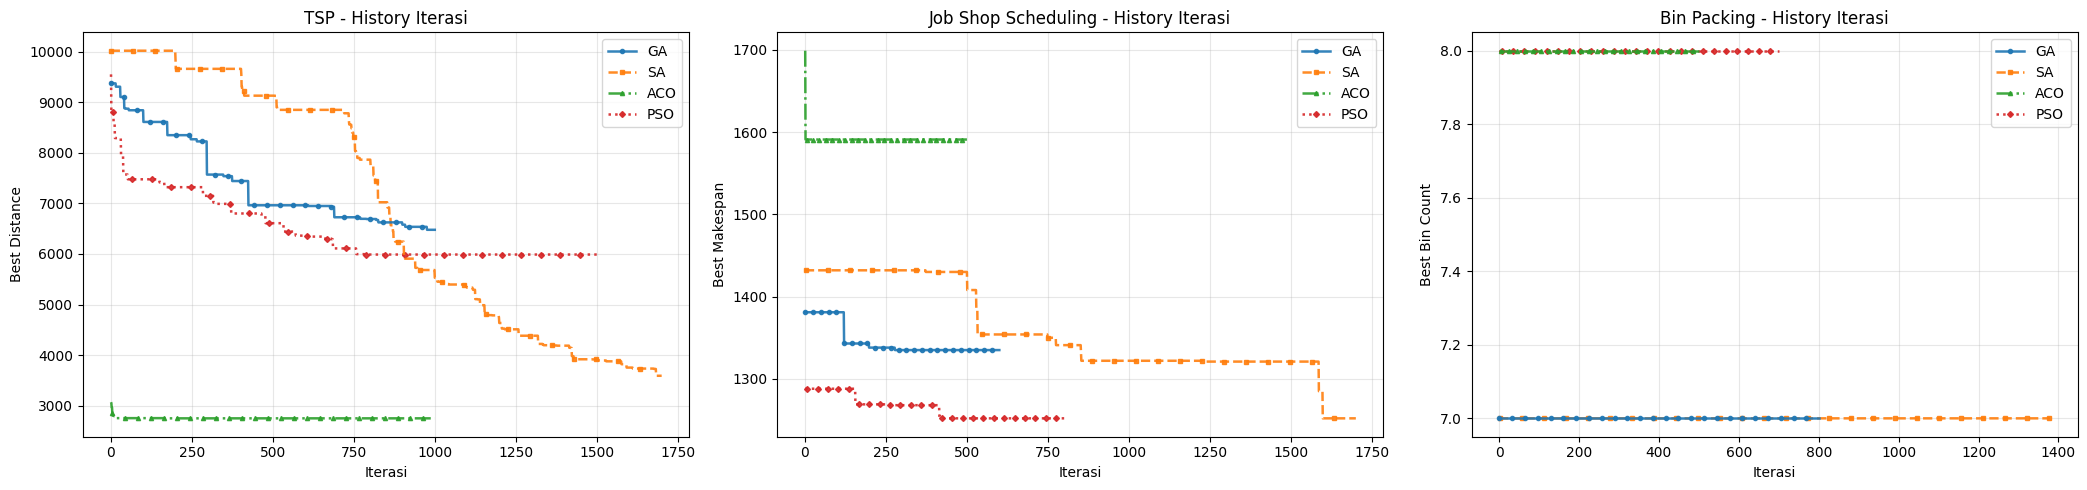

Algoritma paling optimal: SA (Total Rank = 4, Jumlah Menang = 2)

Tabel ringkasan final:


,Algoritma,Rank TSP,Rank Job Shop Scheduling,Rank Bin Packing,Total Rank,Jumlah Menang (Rank 1),Rank Final
0,SA,2,1,1,4,2,1
1,ACO,1,3,2,6,1,2
2,PSO,3,1,2,6,1,2
3,GA,4,2,1,7,1,3


In [39]:
# Evaluasi final lintas 3 dataset (TSP, Job Shop Scheduling, Bin Packing)
algoritma = ["GA", "SA", "ACO", "PSO"]

# Ambil rank per dataset dari tabel evaluasi yang sudah ada
rank_tsp = df_evaluation.set_index("Algoritma")["Rank"]
rank_jss = df_jss_evaluation.set_index("Algoritma")["Rank"]
rank_bp = df_bp_evaluation.set_index("Algoritma")["Rank"]

# Tabel detail lintas dataset agar konsisten dengan evaluasi per dataset
final_detail_rows = []
for _, row in df_evaluation.iterrows():
    final_detail_rows.append({
        "Dataset": "TSP",
        "Algoritma": row["Algoritma"],
        "Nilai Terbaik": float(row["Best Distance"]),
        "Iterasi": int(row["Iterasi"]),
        "Rank Dataset": int(row["Rank"])
    })

for _, row in df_jss_evaluation.iterrows():
    final_detail_rows.append({
        "Dataset": "Job Shop Scheduling",
        "Algoritma": row["Algoritma"],
        "Nilai Terbaik": float(row["Best Makespan"]),
        "Iterasi": int(row["Iterasi"]),
        "Rank Dataset": int(row["Rank"])
    })

for _, row in df_bp_evaluation.iterrows():
    final_detail_rows.append({
        "Dataset": "Bin Packing",
        "Algoritma": row["Algoritma"],
        "Nilai Terbaik": float(row["Best Bin Count"]),
        "Iterasi": int(row["Iterasi"]),
        "Rank Dataset": int(row["Rank"])
    })

df_final_detail = pd.DataFrame(final_detail_rows)

print("Tabel evaluasi lintas dataset:")
display(  # ty:ignore[unresolved-reference]
    df_final_detail.style.format({
        "Nilai Terbaik": "{:.4f}",
        "Iterasi": "{:.0f}",
        "Rank Dataset": "{:.0f}"
    })
)

# Visualisasi history iterasi untuk 3 dataset
dataset_histories = [
    ("TSP", "Best Distance", {
        "GA": tsp_ga_history,
        "SA": tsp_sa_history,
        "ACO": tsp_aco_history,
        "PSO": tsp_pso_history
    }),
    ("Job Shop Scheduling", "Best Makespan", {
        "GA": jss_ga_history,
        "SA": jss_sa_history,
        "ACO": jss_aco_history,
        "PSO": jss_pso_history
    }),
    ("Bin Packing", "Best Bin Count", {
        "GA": bp_ga_history,
        "SA": bp_sa_history,
        "ACO": bp_aco_history,
        "PSO": bp_pso_history
    })
]

fig, axes = plt.subplots(1, 3, figsize=(21, 5))

line_styles = {"GA": "-", "SA": "--", "ACO": "-.", "PSO": ":"}
line_markers = {"GA": "o", "SA": "s", "ACO": "^", "PSO": "D"}
line_zorders = {"GA": 5, "SA": 4, "ACO": 3, "PSO": 2}
marker_offsets = {"GA": 0, "SA": 2, "ACO": 4, "PSO": 6}

for ax, (dataset_name, metric_name, history_map) in zip(axes, dataset_histories):
    for algo in algoritma:
        history_points = history_map[algo]
        iterations = [p[0] for p in history_points]
        metric_values = [p[1] for p in history_points]
        marker_step = max(1, len(iterations) // 25)
        marker_offset = marker_offsets[algo] % marker_step
        ax.plot(
            iterations,
            metric_values,
            label=algo,
            linewidth=1.8,
            linestyle=line_styles[algo],
            marker=line_markers[algo],
            markersize=3.0,
            markevery=(marker_offset, marker_step),
            zorder=line_zorders[algo],
            alpha=0.9
        )

    ax.set_title(f"{dataset_name} - History Iterasi")
    ax.set_xlabel("Iterasi")
    ax.set_ylabel(metric_name)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Tabel ringkasan final per algoritma berdasarkan total rank
final_summary_data = {
    "Algoritma": algoritma,
    "Rank TSP": [int(rank_tsp[a]) for a in algoritma],
    "Rank Job Shop Scheduling": [int(rank_jss[a]) for a in algoritma],
    "Rank Bin Packing": [int(rank_bp[a]) for a in algoritma],
}

df_final_evaluation = pd.DataFrame(final_summary_data)
df_final_evaluation["Total Rank"] = (
    df_final_evaluation["Rank TSP"]
    + df_final_evaluation["Rank Job Shop Scheduling"]
    + df_final_evaluation["Rank Bin Packing"]
)
df_final_evaluation["Jumlah Menang (Rank 1)"] = (
    (df_final_evaluation["Rank TSP"] == 1).astype(int)
    + (df_final_evaluation["Rank Job Shop Scheduling"] == 1).astype(int)
    + (df_final_evaluation["Rank Bin Packing"] == 1).astype(int)
)

df_final_evaluation = df_final_evaluation.sort_values(
    by=["Total Rank", "Jumlah Menang (Rank 1)", "Algoritma"],
    ascending=[True, False, True]
).reset_index(drop=True)

df_final_evaluation["Rank Final"] = df_final_evaluation["Total Rank"].rank(method="dense").astype(int)

# Tentukan pemenang akhir dengan tie-breaker jumlah menang
min_total_rank = df_final_evaluation["Total Rank"].min()
best_candidates = df_final_evaluation[df_final_evaluation["Total Rank"] == min_total_rank]

max_wins = best_candidates["Jumlah Menang (Rank 1)"].max()
best_candidates = best_candidates[best_candidates["Jumlah Menang (Rank 1)"] == max_wins]

if len(best_candidates) == 1:
    best_algorithm_final = best_candidates.iloc[0]["Algoritma"]
    print(
        f"Algoritma paling optimal: {best_algorithm_final} "
        f"(Total Rank = {int(min_total_rank)}, Jumlah Menang = {int(max_wins)})"
    )
else:
    co_best = ", ".join(best_candidates["Algoritma"].tolist())
    print("Algoritma paling optimal: CO-BEST")
    print(
        f"Daftar co-best: {co_best} "
        f"(Total Rank = {int(min_total_rank)}, Jumlah Menang = {int(max_wins)})"
    )

print("\nTabel ringkasan final:")
display(  # ty:ignore[unresolved-reference]
    df_final_evaluation.style.format({
        "Rank TSP": "{:.0f}",
        "Rank Job Shop Scheduling": "{:.0f}",
        "Rank Bin Packing": "{:.0f}",
        "Total Rank": "{:.0f}",
        "Jumlah Menang (Rank 1)": "{:.0f}",
        "Rank Final": "{:.0f}"
    })
)